## General Agent Architechture  with Memory



In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# Set evironment with API
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_USE_V1"] = "true"

In [ ]:
# set LangSmith tracing environment
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ['LANGCHAIN_PROJECT'] = 'langGraph-Course'

In [5]:
# configure LLM
from google import genai
from langchain_google_genai import ChatGoogleGenerativeAI

# set client
client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])

# create LLM
llm = ChatGoogleGenerativeAI(
    model="gemini-flash-lite-latest",
    temperature=0.2
)


In [16]:
# Test LLM
result = llm.invoke("Hi what can you do?")
result.content[0]['text']

'I am a large language model, trained by Google. You can think of me as a knowledgeable assistant that can help you with a wide variety of tasks.\n\nHere is a breakdown of what I can do for you:\n\n### 1. Writing and Content Creation\n*   **Drafting:** I can write emails, essays, cover letters, blog posts, or reports.\n*   **Creative Writing:** I can write stories, poems, scripts, song lyrics, or jokes.\n*   **Editing:** I can proofread your writing, fix grammar, change the tone (e.g., make it more professional or friendly), or summarize long documents.\n\n### 2. Learning and Information\n*   **Explaining Concepts:** I can explain complex topics (like quantum physics or how a mortgage works) in simple terms.\n*   **Answering Questions:** I can provide facts, historical context, or general knowledge on almost any subject.\n*   **Summarization:** Paste a long article or transcript, and I can give you the key bullet points.\n\n### 3. Technical Tasks\n*   **Coding:** I can write code in ma

# create tools

In [21]:
# addition
def add(a:float , b:float):
    """add two numbers
    arg:
    a = first num ->float
    b = second num ->float
    return int
    """
    return a + b
# multiply
def multiply(a:float , b: float):
    """ multiply 2 numbers
    arg:
    a = first num ->float
    b = second num ->float
    return flaot   """
    return a * b
# divide
def divide(a:float , b:float):
    """divide a number by another
    arg:
    a = first num ->float
    b = second num ->float
    return float"""
    return a/b

tools  = [add, multiply , divide]




## Bind tools

In [24]:
llm_with_tools = llm.bind_tools(tools)

# test
print(llm_with_tools.invoke("what are the tools available?").content[0]['text'])

I have access to the following tools:

*   **`add(a, b)`**: Adds two numbers.
*   **`multiply(a, b)`**: Multiplies two numbers.
*   **`divide(a, b)`**: Divides the first number by the second.

You can ask me to perform calculations using these tools!


## Create state , add system message and Memory

In [43]:
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage , HumanMessage

sys_msg = SystemMessage( role = "Model" , content = "You are a arithmatic operator who performs calculations using the tools available." , name ='LLM')

# create Nodes with Memory

# Node 1 function
def llm_assistant(state:MessagesState):
    messages = [sys_msg] + state['messages']
    response = llm_with_tools.invoke(messages)
    #print(f"Response: {response}")
    print(f"Sgtate_Message: {state['messages']}")
    return {'messages': [response] + state['messages']} # state message adds old message and response is new message 

## Build a graph , add nodes and edges

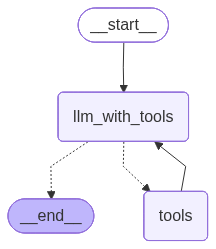

In [44]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode , tools_condition

builder = StateGraph(MessagesState)

# add nodes
builder.add_node('llm_with_tools' , llm_assistant)
builder.add_node('tools' , ToolNode(tools))

# add edges
builder.add_edge(START , "llm_with_tools")
builder.add_conditional_edges('llm_with_tools', tools_condition,)
builder.add_edge('tools', 'llm_with_tools')

graph = builder.compile()
graph

In [45]:
result = graph.invoke({'messages':[HumanMessage(role='user' , content = 'add 230 and 340 and divide them by 2' , name = 'diya')]})

Sgtate_Message: [HumanMessage(content='add 230 and 340 and divide them by 2', additional_kwargs={}, response_metadata={}, name='diya', id='bc74405f-f4ea-4877-b74b-57fb0a627209', role='user')]
Sgtate_Message: [HumanMessage(content='add 230 and 340 and divide them by 2', additional_kwargs={}, response_metadata={}, name='diya', id='bc74405f-f4ea-4877-b74b-57fb0a627209', role='user'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'add', 'arguments': '{"b": 340, "a": 230}'}, '__gemini_function_call_thought_signatures__': {'7027b330-6a39-4fac-899b-08b06bb27910': 'EjQKMgEMOdbHDr8Zfu7rDGnGQHui3ri1ISjXNOm8614mYDGqkYyatIWDNudmMq9R5xchmeVE'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d98f1-bf3c-7020-ae91-bf930136c402-0', tool_calls=[{'name': 'add', 'args': {'b': 340, 'a': 230}, 'id': '7027b330-6a39-4fac-899b-08b06bb27910', 'type': 'tool_call'}], invalid_to

In [46]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================
Name: diya

add 230 and 340 and divide them by 2
================================== Ai Message ==================================

[]
Tool Calls:
  add (7027b330-6a39-4fac-899b-08b06bb27910)
 Call ID: 7027b330-6a39-4fac-899b-08b06bb27910
  Args:
    b: 340
    a: 230
================================= Tool Message =================================
Name: add

570.0
================================== Ai Message ==================================

[]
Tool Calls:
  divide (da887996-ff21-48af-9a99-df6c145edd0c)
 Call ID: da887996-ff21-48af-9a99-df6c145edd0c
  Args:
    b: 2
    a: 570
================================= Tool Message =================================
Name: divide

285.0
================================== Ai Message ==================================

[{'type': 'text', 'text': 'The result of adding 230 and 340, and then dividing by 2, is 285.', 'extras': {'signature': 'EjQKMgEMOdbHuiZJd7t2LvRLVti8Zh

In [39]:

msg = HumanMessage(role='user' , content = 'now multiply that by 2' , name = 'diya')
result = graph.invoke({'messages':[msg]})
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================
Name: diya

now multiply that by 2
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (2e4cadf9-db97-44b8-8d90-7aff3a540086)
 Call ID: 2e4cadf9-db97-44b8-8d90-7aff3a540086
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: multiply

4.0
================================== Ai Message ==================================

[{'type': 'text', 'text': 'The result is 4.', 'extras': {'signature': 'EjQKMgEMOdbHDHqZWLpRDt5r/Qn5mctGtFec1D/lKftt5qWKTWLV+FPRtsGpfWWFAt7LCJSx'}}]


# Memory

##### state is transient . data ['messages'] are available to only 1 execution. state recreates itself and expires after the run everytime graph is invoked.
 - this limits our ability to have multi-turn conversations with interruptions.

### Solution: Persistence

- LangGraph has a built-in persistence layer that saves graph state as checkpoints.
- This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update.
- One of the easiest checkpointers to use is the `MemorySaver`, an in-memory key-value store for Graph state.
- All we need to do is simply compile the graph with a checkpointer, and our graph has memory!

#### Thread ID
thread_id will store our collection of graph states.
A thread ID is the unique identifier for a conversation’s state, allowing LangGraph agents to remember context across multiple invocations.
   -  The checkpointer write the state at every step of the graph
   -  These checkpoints are saved in a thread
   -  We can access that thread in the future using the thread_id

##### It is a memory container for one user.  Every time you run a graph with persistence enabled, LangGraph stores the state under a thread ID so it can be retrieved later.